# Figure SX: Historical vs. PiControl SWCF

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import xarray as xr
import xcdat as xc
import xskillscore as xscore
from scipy.stats import linregress

# Ignore xarray warnings (bad practice)
import warnings
warnings.simplefilter("ignore") 

# Utils

In [37]:
def detrend(da):
    time_idx = xr.DataArray(np.arange(len(da.time), dtype="float32"), dims="time")
    slope = xscore.linslope(time_idx, da, dim="time", skipna=True)
    da = da - slope*time_idx
    return da 

def calculate_cf(tos: xr.Dataset, swcre: xr.Dataset, save: bool = False, save_name: str = "") -> xr.Dataset:
    """Calculate the shortwave cloud feedback (swcf)

    Definition 1:
    swcf = dR_swcre / dSST (Wm^-2/K)

    Definition 2:
    swcre_anoms = swcf * SST_anoms + b

    Args:
        tos (xr.Dataset): monthly sst anomalies
        swcre (xr.Dataset): monthly swcre anomalies
        save (bool, optional): Defaults to False.
        save_name (str, optional): Defaults to "".
Ahjhvi
    Returns:
        swcf (xr.Dataset): dimensions (model, time, lat, lon)
    """
    # Rechunk along time dimension
    tos = tos.chunk({'time': -1})
    swcre = swcre.chunk({'time': -1})

    tos = remove_land_full(tos, var="tos")
    swcre = remove_land_full(swcre, var="swcre")

    shared_models = list(set(tos.model.values).intersection(set(swcre.model.values)))

    # Calculate the correlation coefficient
    # dcre(x,y)/dsst(x,y)
    swcf = xscore.linslope(tos.sel(model=shared_models), swcre.sel(model=shared_models), dim='time', skipna=True)

    swcf_all = xr.Dataset({
        "swcf": swcf, 
    })
    return swcf_all

def fix_coords(data):
    data = data.bounds.add_bounds("X")
    data = data.bounds.add_bounds("Y")
    data = xc.swap_lon_axis(data, to=(-180, 180))
    return data

# Get shared models between swcf_eastsa_cmip6 and tos_grad_trend_cmip6
def get_shared_models(ds1, ds2):
    shared_models = list(set(ds1.model.values).intersection(set(ds2.model.values)))
    return ds1.sel(model=shared_models), ds2.sel(model=shared_models)

def remove_land_full(ds, var="skt"):
    ds = ds.rename(var).to_dataset()
    ds = xc.swap_lon_axis(ds, to=(-180, 180))
    from global_land_mask import globe
    # Set land to NaN
    lon_grid,lat_grid = np.meshgrid(ds.lon, ds.lat)
    globe_land_mask = globe.is_land(lat_grid,lon_grid)
    globe_land_mask_nd = np.tile(globe_land_mask,(ds[var].shape[0],ds[var].shape[1], 1,1))
    ds_no_land = xr.where(globe_land_mask_nd==True,np.nan,ds[var]) 
    return ds_no_land

# Load and Preprocess

In [34]:
# SWCF EPSA
swcf_cmip6_epsa = xr.open_dataarray("/home/espinosa10/tropical_pacific_clouds/data/piControl/swcf_east_sa_cmip6_v3.nc") 
swcf_cmip5_epsa = xr.open_dataarray("/home/espinosa10/tropical_pacific_clouds/data/piControl/swcf_east_sa_cmip5_v3.nc") 
swcf_cmip_epsa = xr.concat([swcf_cmip6_epsa, swcf_cmip5_epsa], dim="model")

In [35]:
obs_swcf = xr.open_dataset(f"/home/espinosa10/SO-EP-teleconnection/Data/obs/swcf-toa-obs-epsa.nc").swcf.values

In [31]:
cre = xc.open_dataset("/home/espinosa10/tropical_pacific_clouds/data/historical/swcre_cmip6_monthly_1850-2000.nc", chunks={"time": -1})
cre_anoms = xc.open_dataset("/home/espinosa10/tropical_pacific_clouds/data/historical/swcre_cmip6_anoms_monthly_1850-2000.nc", chunks={"time": -1})
tos_cmip6 = xc.open_dataset("/home/espinosa10/tropical_pacific_clouds/data/historical/tos_mon_1850-2100_CMIP6_historical.nc", chunks={"time": -1})
tos_anoms_cmip6 = tos_cmip6.temporal.departures("tos", "month").chunk({"time": -1})

In [32]:
tos_cmip6["tos"] = detrend(tos_cmip6.tos)
tos_anoms_cmip6["tos"] = detrend(tos_anoms_cmip6.tos)
cre_anoms["swcre_anoms"] = detrend(cre_anoms.swcre_anoms)
cre["swcre"] = detrend(cre.swcre)

In [46]:
cf_cmip6 = calculate_cf(tos_anoms_cmip6["tos"], cre_anoms["swcre_anoms"], save=False, save_name="cmip6")
cf_cmip6 = fix_coords(cf_cmip6)
cf_cmip6_epsa = cf_cmip6.sel(lon=slice(-105, -70), lat=slice(-40, -10))
cf_cmip6_epsa = cf_cmip6_epsa.spatial.average("swcf")["swcf"]
cf_cmip6_epsa

2025-07-16 11:52:15,579 [WARNING]: bounds.py(_create_bounds:398) >> The 'lat' coordinate variable is missing a 'units' attribute. Assuming 'units' is 'degrees_north'.


<xarray.DataArray 'swcf' (model: 50)>
dask.array<truediv, shape=(50,), dtype=float64, chunksize=(50,), chunktype=numpy.ndarray>
Coordinates:
  * model    (model) object 'FGOALS-f3-L' 'CAMS-CSM1-0' ... 'NorCPM1'

# Plotting Utils

In [40]:
def create_panel_a(ax, x6, y6, x5: list = [], y5: list = [], vline=0) -> None:
    # Set the default color cycle
    colors = ['black','maroon','#7570b3']
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

    CMIP6_label = "CMIP6"
    
    if len(x5) != 0: 
        slope, intercept, r, p, _ = linregress(x5,y5)
        r, p = np.around(r, 3), np.around(p, 3)
        CMIP5_label = f"r={r}"
        ax.scatter(x5, y5, s=100, alpha=.5, edgecolor="black", color=colors[0], label=CMIP5_label)

        slope, intercept, r, p, _ = linregress(x6,y6)
        r, p = np.around(r, 3), np.around(p, 3)
        CMIP6_label = f"r={r}"
    
    ax.scatter(x6, y6, s=100, alpha=.5, edgecolor="black", color=colors[0], label=CMIP6_label)

    # Multimodel mean
    mmm = np.mean([*x5, *x6])


    x = np.concatenate((x6, x5))
    y = np.concatenate((y6, y5))
    # Sort the lists together based on list1
    x, y  = zip(*sorted(zip(x, y)))

    slope, intercept, r, p, _ = linregress(x,y)
    r, p = np.around(r, 3), np.around(p, 3)
    if p < .05: 
        sig = '*'
    else: 
        sig = ''
    print(r, p)

    x = np.array(sorted(x))
    ax.plot(x, x*slope+intercept, color="black")
    # ax.legend(loc="upper left", fontsize=fontsize)
    ax.set_title(f"r={r}{sig}", loc="right", fontweight="bold", fontsize=16)
    
    
    # Define border size - important for emphasizing relationships
    xmin, xmax = np.min(x), np.max(x)
    ymin, ymax = np.min(y), np.max(y)
    borderx, bordery = .25*abs(np.max(x)), .25*abs(np.max(y))
    ax.set_xlim(xmin-borderx, xmax+borderx)
    ax.set_ylim(ymin-bordery, ymax+bordery)

    # Vertical line for avg and std of obs
    ax.vlines(np.mean(vline), ymin=ymin-bordery, ymax=ymax+bordery, color="navy")
    ax.fill_between(x=[np.mean(vline) - np.std(vline), np.mean(vline) + np.std(vline)], y1=ymin-bordery, y2=ymax+bordery,color="navy", alpha=.25)

    # Add Model Vertical Lines
    ax.vlines(mmm, ymin=ymin-bordery, ymax=ymax+bordery, color=colors[0], label='_nolegend_', alpha=.5, linewidth=2, zorder=0) 
    # ax.fill_between(x=[mmm - np.std(x), mmm + np.std(x)], y1=-1, y2=2.5, color="black", alpha=.25)
    ax.fill_between(x=[mmm - np.std(x), mmm + np.std(x)], y1=np.min(y)*5-50, y2=np.max(y)*5+50, color="black", alpha=.25)

    # Add horizontal sigma lines
    sig_mmm = mmm*slope+intercept
    sig_obs = np.mean(vline)*slope+intercept
    hline_width = 3
    ax.hlines(y=sig_mmm, xmin=xmin-borderx, xmax=mmm, color="black", linewidth=hline_width)
    ax.hlines(y=sig_obs, xmin=xmin-borderx, xmax=np.mean(vline), color="orange", linewidth=hline_width)

    ax.text(s=f"{np.around(sig_mmm, 2)}", x=xmin-borderx*.95, y=sig_mmm + sig_mmm*.025, color="black", fontsize=12, fontweight="bold")
    ax.text(s=f"{np.around(sig_obs, 2)}", x=xmin-borderx*.95, y=sig_obs + sig_mmm*.025, color="orange", fontsize=12, fontweight="bold")


# Figure SX: Historical vs. PiControl SWCF

0.993 0.0


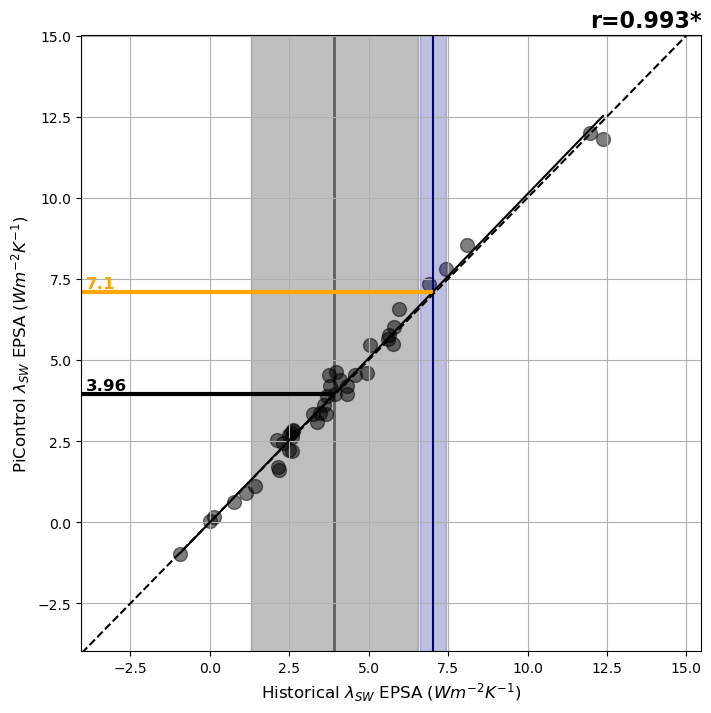

In [50]:
title_fontsize = 14
# Create figure and gridspec
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(1, 1)
# Create scatter plots (top row)
ax1 = fig.add_subplot(gs[0, 0])

######## SWCF EPSA vs dEPT/dSO ############
y, x = get_shared_models(swcf_cmip_epsa, cf_cmip6_epsa)

create_panel_a(ax1, x.values, y.values, vline=obs_swcf)
# Add one to one line
ax1.plot(np.arange(-5, 16, 1), np.arange(-5, 16, 1), color="black", linestyle="--", linewidth=1.5, label="_nolegend_")
ax1.set_xlabel(r"Historical $\lambda_{SW}$ EPSA ($Wm^{-2}K^{-1}$)", fontsize=12)
ax1.set_ylabel(r"PiControl $\lambda_{SW}$ EPSA ($Wm^{-2}K^{-1}$)", fontsize=12)
ax1.grid()
plt.savefig("/home/espinosa10/SO-EP-teleconnection/Manuscript_Figures/SI/swcf_historical_vs_piControl.png", dpi=300, bbox_inches="tight")
plt.savefig("/home/espinosa10/SO-EP-teleconnection/Manuscript_Figures/SI/swcf_historical_vs_piControl.pdf", dpi=300, bbox_inches="tight")